# Some Basic Ways to Plot Ground Motions from the RSQSim Catalog Using Openquake Python Package

### Author Evan Marschall (emarschall@ucsd.edu,emars009@ucr.edu)

#### In Collaboration with Bruce Shaw and Alice-Agnes Gabriel

### Last updated March 2026

In this notebook I will walk through some basic ways to generate ground motions for from the RSQSim outputs. In the examples in this notebook I will use the the openquake python package.

If you are looking for basics on manipulating the RSQSim outputs please see the " Getting Started Post Processing" notebook.

For the old-write output style, RSQsim will output several different files used in thiss notebook

OUTPUTS from RSQSim used in this notebook:

eqs.filename.out : This is the file that has all the cataloged events

filename.eList : This file has all the events which slip,stress,etc are recorded at each element (Binary)

filename.pList : This file contains the patches that participated (Slipped) in each event from the .eList file (Binary)


OTHER FILES NEEDED:

filename.flt : This is the original fault file you used to run the simulation. This will be importnat to have in your working directory

Important Note: This assumes you have already ran the RSQSim simulations and have the old-write-style output

### Step 1: Import Dependencies: Will need Scipy and Openquake 
I needed to do some compatibilty patches because the numpy used in open quake is old.

In [26]:
import numpy as np
import pandas as pd
import utm 
import matplotlib.pyplot as plt
import random
import math
import os

import warnings
#patch numpy, openquake is old
# Patch NumPy 2.0 compatibility before importing openquake

# --- NumPy 2.0 Compatibility Patch ---
if not hasattr(np, 'RankWarning'):
    # RankWarning was moved to numpy.exceptions
    np.RankWarning = getattr(np, 'exceptions', warnings).RankWarning

if not hasattr(np, 'string_'):
    # string_ was renamed to bytes_
    np.string_ = np.bytes_

if not hasattr(np, 'unicode_'):
    # unicode_ was renamed to str_
    np.unicode_ = np.str_

if not hasattr(np, 'warnings'):
    # Some older libs expect np.warnings to be the standard warnings module
    np.warnings = warnings
# -------------------------------------
from openquake.hazardlib.gsim.boore_2014 import BooreEtAl2014
from openquake.hazardlib.imt import PGA
from openquake.hazardlib.const import StdDev
from openquake.hazardlib.gsim.base import SitesContext, RuptureContext, DistancesContext
from openquake.hazardlib.imt import SA



from scipy.spatial import KDTree

from scipy.interpolate import NearestNDInterpolator


# Also Here I define a function that makes it easy to find nearest distances from fault to point on the surface points
number_neighbors = 1 #  nearest x,y ruptuted point 
def find_nearest_point_kdtree(query_point, points_array):
        tree = KDTree(points_array)
        distance, index = tree.query(query_point,k=number_neighbors)
        return index, distance


### Step 2: Set up file paths and read in rsqsim files
Direct where the input files are and where outputs should go

In [27]:
indir = "/Users/emarschall/Desktop/RSQSim_stuff/step_over/step_over1_outputs/" # directory containing the RSQSim outputs: will need to modify 
outdir = indir #Directory where you want to save plots and what not 
filename = "step_over_test"
event_file = "eqs."+filename+".out" # this is the file which conatins all the events
fault_file = "Step_over.flt" # Name of your fault file 
## These files are Binary ##
e_file = filename+".eList" # Event number
p_file = filename+".pList" # list of patches in each event

## I like to make a folder to keep all the ground motion (gmm) figures
folder_name = outdir + "gmm_figures/"
try:
    os.makedirs(folder_name, exist_ok=True)
    print(f"Folder '{folder_name}' exists.")
except OSError as e:
    print(f"Error creating folder: {e}")


# Read in the event file
## must first find the number of lines to skip (These are often the input parameters used in the run)
starting_index =[]
beginning_string = "%%% end input files"
with open(indir+event_file, 'r') as file:
    for line_num, line in enumerate(file, 0):
        if beginning_string in line:
            print(f"Found '{beginning_string}' on line {line_num}: {line.strip()}")
            starting_index.append(line_num)
file.close()

col_names = ["t","Mo","Mw","nuc_x","nuc_y","nuc_z","area","duration","nuc_element"]
df_events_raw = pd.read_csv(indir+event_file, sep = " ", header =None, skiprows = starting_index[0]+1, names =col_names)

# Read in the fault file
fault = pd.read_csv(indir+fault_file, sep = " ", header =None)


#Read in the binary Files
data_events = np.fromfile(indir+e_file, dtype=np.int32) # Events
data_patches = np.fromfile(indir+p_file, dtype=np.int32) # Patches in each rupture 

Folder '/Users/emarschall/Desktop/RSQSim_stuff/step_over/step_over1_outputs/gmm_figures/' exists.
Found '%%% end input files' on line 52539: %%% end input files


### Step 3: Making a spectral acceleration plot for a single station for a single event
In this section we will generate a spectral acceleration plot for 1 location froma single event  

Please note that this will be a simplified example, we will assume a uniform vs30 and will model the ground motions using the Boore et al 2014 methodology

In this example we will use the same event which we plotted in the Getting_Started Notebook  







In [28]:
# the first thing we will do is set up contexts for the gmm calculations
site = SitesContext() # this is where we will store the site information
rupt = RuptureContext() # This is where we store the rupture information
dist = DistancesContext() # This is where we store the distance information

# Lets pick our earthquake after removing spin up time (See the Previous getting started notebook)
spin_up_time = 0 #years
sec2yr = 3600*24*365.25
df_events_raw.t = df_events_raw.t/(sec2yr) #change from seconds to years 
#Remove the spin-up time events
df_spin_up = df_events_raw[(df_events_raw.t>= spin_up_time)]
Target_Event_index = df_spin_up[df_spin_up.Mw.values == np.max(df_spin_up.Mw.values)].index +1


# Define the rupture 
rupt.mag = np.max(df_spin_up.Mw.values) #Here we assign the magnitude of the rupture
rupt.rake = 180 # You can get this from the fault file 

# Lets define some distances, here we will assume the we want to look at a location that is 5 km away from the rupture, perpendicualr to the rupture plane
dist.rjb = np.array([5.0]) # RJB distance
dist.rx = np.array([5.0]) # Distance perpendicular to fault 
dist.rrup = np.array([5.0]) # Distance from rupture 

# Lets define some site characteristics
site.vs30 = np.array([700.0]) #VS 30 m/s
site.vs30measured = np.array([True]) # Set as True
site.sids = np.array([0], dtype=np.uint32) # Site ids





Now lets actaully go through and find the spectral accelerations we will use the Boore 2014 Model

0.01         | 0.3556         
0.05         | 0.4789         
0.10         | 0.6999         
0.20         | 0.8453         
0.30         | 0.7286         
0.50         | 0.5224         
1.00         | 0.2700         
2.00         | 0.1060         
4.00         | 0.0449         


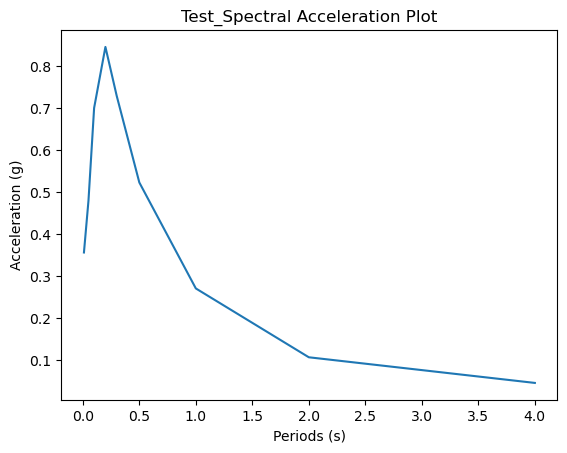

In [29]:
gsim = BooreEtAl2014() # We are susing the Boore et al., 2014 model

#Which periods do we want to calculate the spectral acceleration
periods = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0, 4.0]
results = [] # This is an empty list where we will store the mean spectral value

#Now lets get the mean acceleration for eaxh period 
for T in periods:
    # SA(period, damping=5.0)
    imt = SA(period=T, damping=5.0)
    
    # Calculate (results in natural log units)
    mean, _ = gsim.get_mean_and_stddevs(site, rupt, dist, imt, [StdDev.TOTAL])
    
    median_g = np.exp(mean[0]) #mean[0] is ln(SA)
    results.append(median_g)
    print(f"{T:<12.2f} | {median_g:<15.4f}")


fig , ax = plt.subplots()
ax.set_title("Test_Spectral Acceleration Plot")
ax.set_ylabel("Acceleration (g)")
ax.set_xlabel("Periods (s)")
ax.plot(periods,results)
fig.savefig(folder_name +"Spectral Acceleration")

### Step 4: Making a peak ground acceleration map

In the last section we plotted spectral acceleration for a single station, but sometimes it is useful to see things in a map view.  

In this section we will plot peak ground acceleration in a gridded map

In [30]:
# First we will make a flat free surface and make it into a gridded 1km x 1km grid
# We will base the map domain off of the min, max x-y points in our model domain
domain_buffer = 20000 #meters, how much larger than the faulkt do me want our domain
interval  = 1000 # The grid spacing in meters

xlower = min(fault[0].values) - domain_buffer
ylower = min(fault[1].values) - domain_buffer
xupper= max(fault[0].values) + domain_buffer
yupper= max(fault[1].values) + domain_buffer

# Make it into a mehsgrid
x_values = np.linspace(xlower, xupper, int(np.floor(xupper-xlower)/interval)) 
y_values = np.linspace(ylower, yupper, int(np.floor(yupper-ylower)/interval))
X, Y = np.meshgrid(x_values, y_values)

 ##### Although we are using the same event as above, for completeness I will redefine all the variables 
 This section may take up abit longer to run but should be less than 1 minute.

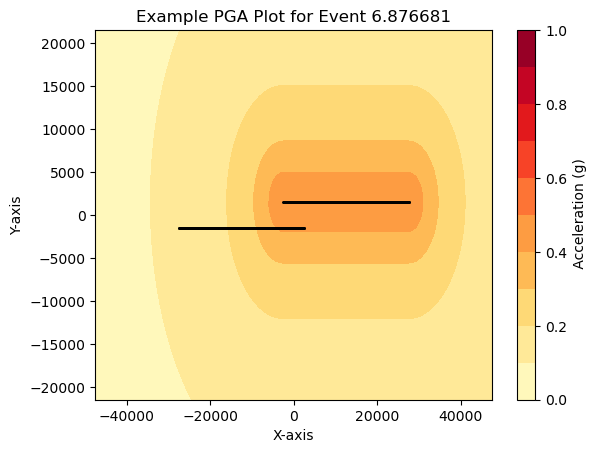

In [31]:
#This is all the same as step 3
site = SitesContext() # this is where we will store the site information
rupt = RuptureContext() # This is where we store the rupture information
dist = DistancesContext() # This is where we store the distance information
spin_up_time = 0 #years
sec2yr = 3600*24*365.25
df_events_raw.t = df_events_raw.t/(sec2yr) 
df_spin_up = df_events_raw[(df_events_raw.t>= spin_up_time)]
Target_Event_index = df_spin_up[df_spin_up.Mw.values == np.max(df_spin_up.Mw.values)].index +1
rupt.mag = np.max(df_spin_up.Mw.values) # Magnitude
rupt.rake = 180 # Rake
site.vs30 = np.array([700.0]) #VS 30 m/s
site.vs30measured = np.array([True]) # Set as True
site.sids = np.array([0], dtype=np.uint32) # Site ids
## This is new stuff, we will define the distances here, again we are simplifying everything by using a Boore et al model which only needs a few distance paramters
indices_patches = np.where(data_events == Target_Event_index[0])[0]
patches = data_patches[indices_patches] -1 #This is a list of the patches which ruptured during the event, -1 to get back to zero indexing we used in our faces mesh

# Here we will only take the location of 1 node of the surface, if we took the mean then we would never get z_top = 0, which means we would never get surface rupture
# Feel free to adapt as you see best fit
x = fault[0].values[patches]
y = fault[1].values[patches]
z = fault[2].values[patches]

rjb = np.empty((len(X), (len(X[0]))))
points = []
z_top = (max(z)) # Rememebr Z is depth, therefore the max value is closest to the surface

# Make a list of all x,y points that ruptured on the fault plane during the event
for xx, yy in zip(x, y): 
    points.append([xx, yy])
# Loop through all grid points to find the rjb distance of each grid point to the closest ruptured location on the fault 
for ii in range(len(X)):
    for jj in range(len(X[0])):
        nn = find_nearest_point_kdtree([X[ii,jj],Y[ii,jj]],points) # finds nearest point on the fault to the [iith,jjth] grid point
        rjb[ii,jj] = nn[1] # the distance from the nearest ruptured point to the grid point
r_rup = np.sqrt(rjb**2 + z_top**2) # This assumes the fault is vertical 


## Now we calculate the the peak ground motion at each grid point
Ground_accel = np.empty((len(X), (len(X[0]))))
for ii in range(len(X)):
        for jj in range(len(X[0])):
            imt = PGA() 
            dist.rjb = rjb[ii,jj]/1000 # need to divide by 1000 because it expects input to be in km
            dist.rup = r_rup[ii,jj]/1000 # need to divide by 1000 because it expects input to be in km
            # Calculate (results in natural log units)
            mean, _ = gsim.get_mean_and_stddevs(site, rupt, dist, imt, [StdDev.TOTAL])
            median_g = np.exp(mean[0]) #mean[0] is ln(PGA)
            Ground_accel[ii,jj] = median_g



# Now we plot the ground motion and the fault trace
plot_faults = fault[((fault[2] >= -500))] #fault trace
fig, ax = plt.subplots() #
contour_levels = np.linspace(0, 1, 11)
contour_plot = ax.contourf(X, Y, Ground_accel, cmap='YlOrRd',levels=contour_levels, alpha = 1)
ax.scatter(plot_faults[0].values,plot_faults[1].values,s=0.5,c ="k")
fig.colorbar(contour_plot, ax=ax,label = " Acceleration (g)")
ax.set_title("Example PGA Plot for Event "+ str(np.max(df_spin_up.Mw.values)))
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
fig.savefig(folder_name +"PGA Map")



# That is all
### Hopefully this was helpful
If you have any questions feel free to reach out to Evan Marschall 